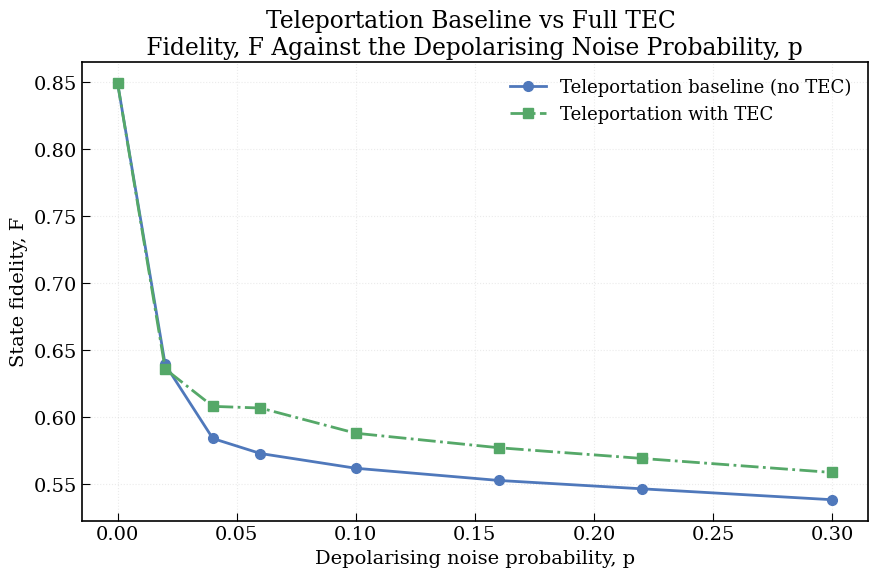

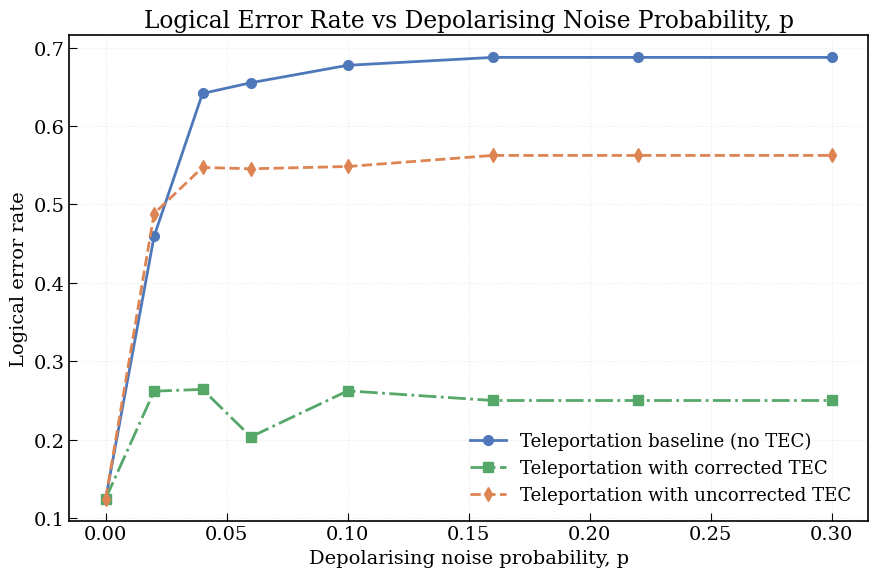

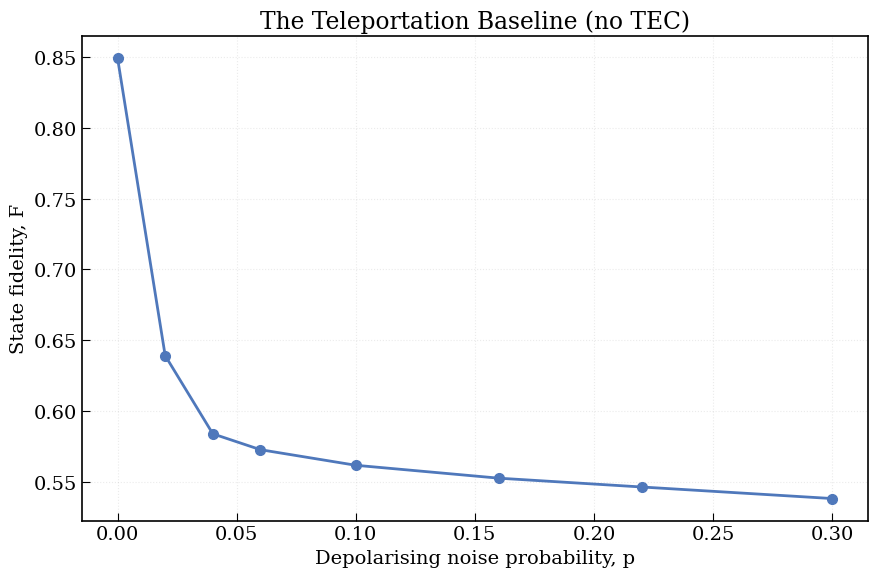

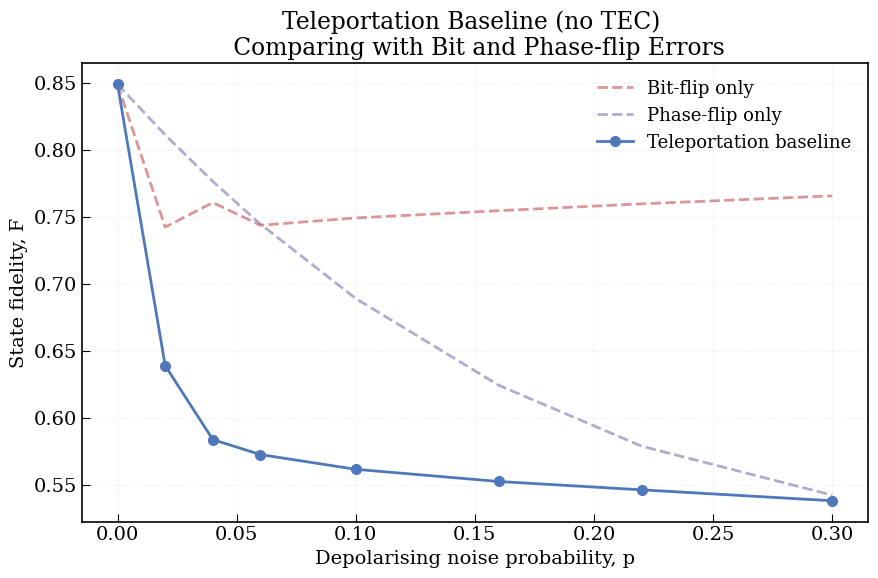

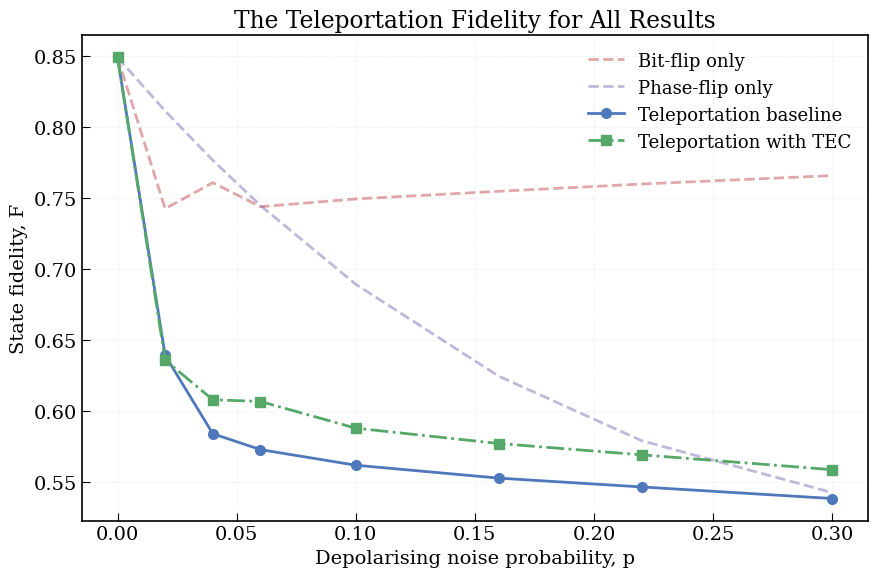

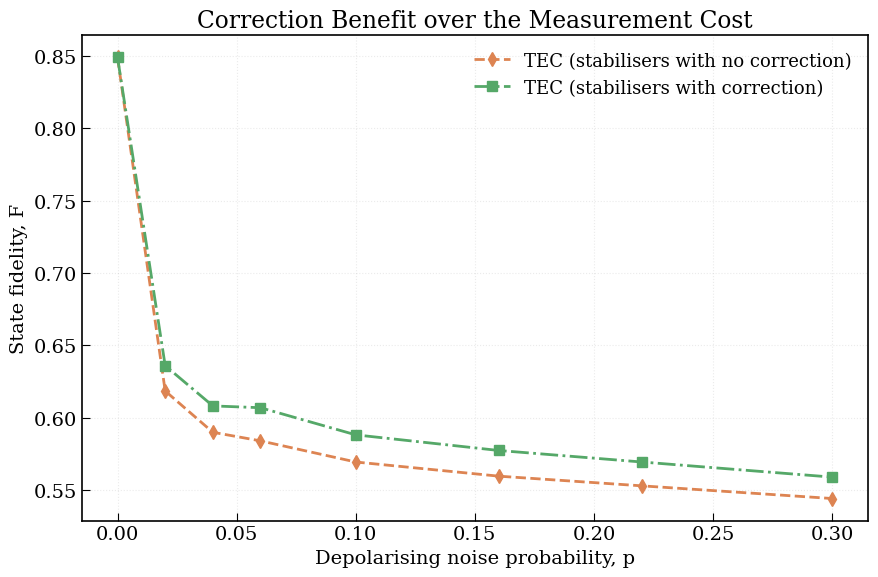

In [5]:
#_____________________________________________________________________________________________________________________
# PART I:
# Teleportation Error Correction (TEC) - Sandra Nodar Sanchez
#
# This script implements a small but complete framework to study the cases:
#
#   Case 1: Teleportation of a single logical qubit encoded in a three qubit
#           repetition code, without any error correction implemented (no TEC).
#
#   Case 2: Teleportation of the same logical qubit in case 1, but now protected 
#           by TEC using stabiliser measurements and additional conditional corrections.
#
#          
# The goal of this work is to compare the following:
#   - The (Pauli reconstructed) fidelity, F vs the physical parameterised noise, p 
#   - Logical error rate vs the physical parametrised noise,p
#
# Furthermore, evaluate in a controlled setting, how TEC suppresses the logical errors
# relative to the baseline encoded teleportation without stabilser corrections.
#_____________________________________________________________________________________________________________________

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import DensityMatrix, state_fidelity, Operator
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, pauli_error

#_____________________________________________________________________________________________________________________
# The fixed input state (Case 1: Teleportation without TEC)
#
# A single, random pure qubit state |ψ⟩ is prepared and kept fixed for all the simulations. This is the state 
# teleported from Alice to Bob.
# Using a fixed state, held by Alice, makes it easier to compare the different noise models and error-correction methods.
# 
# The state is parameterised on the Bloch sphere as follows:
#
#   |ψ⟩ = cos(θ/2)|0⟩ + e^{iφ} sin(θ/2)|1⟩
#
# where θ ∈[0,π] and φ∈[0,2π] is a uniform distribution over the Bloch sphere.
#_____________________________________________________________________________________________________________________

# Fixes randomness of the qubit sate for reproducibility
np.random.seed(42)  

# Sample a random point on the Bloch sphere
w, v = np.random.uniform(0, 1, 2)
theta = np.arccos(1 - 2*w)
phi   = 2*np.pi*v

# Construct the input state vector |ψ⟩
input_state = np.array(
    [np.cos(theta/2), np.exp(1j*phi)*np.sin(theta/2)],
    dtype=complex
)

# Store the target state as a 2x2 density matrix for later fidelity comparisons
dm_target = DensityMatrix(input_state)

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# KEY element for plotting and computing time
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# Range of physical noise probabilities p to explore
#     - eight points selected as a balance
#     - Density is higher in the low noise range where more sensitive 
# ------------------------------------------------------------------------------
# Performance note:
#
# Increasing the number of noise points dramatically increases runtime.
# For each value of the physical noise probability p, the code runs:
#
#   1) Baseline teleportation (no TEC)
#   2) Full TEC (stabilisers + correction)
#   3) TEC detection only (stabilisers, no correction)
#   4) bit-flip noise only
#   5) phase-flip noise only
#
# This amounts to five separate density matrix simulations per noise point.
#
# Each density matrix simulation further branches over many conditional
# classical outcomes (from teleportation measurements and syndromes),
# making the total computational cost scale rapidly.
# -------------------------------------------------------------------------

noise_p = np.array([0.0, 0.02, 0.04, 0.06, 0.10, 0.16, 0.22, 0.30])

#_____________________________________________________________________________________________________________________
# Case 1: The teleportation protocol (encoded teleportation without TEC)
#
# In this section we build the core teleportation protocol, using only the three qubit repetition code. The idea is
# the following:
#
#   1. Encode the input state |ψ⟩ into a logical qubit using the repetition
#      code: |0_I⟩ = |000⟩, |1_I⟩ = |111⟩.
#
#       Majority vote system such that if single qubit flips |000> ---> |010> , error can be detected by which one of 
#       the three qubits |q0q1q2⟩ do not correspond to the other two. 
#
#   2. Prepares the encoded Bell pair between Alice and Bob.
#
#   3. Performs a teleportation protocol by applying CNOT and Hadamard gates between the input block and Alice's block,
#      and then measure and apply the Pauli frame corrections on Bob's block.
#      
#
# The noise is inserted on the input block with identity gates, which are later
# used to apply the noise model.
#_____________________________________________________________________________________________________________________

def encode_repetition(qc, q, state):
    """
    Encode a single-qubit state |ψ⟩ into the 3-qubit repetition code.

    The repetition code protects against bit-flip (X) errors by redundantly
    encoding the logical qubit across three physical qubits:

        |0_L⟩ = |000⟩
        |1_L⟩ = |111⟩

    - Initialise qubit q[0] in |ψ⟩ and Copy its state to q[1] and q[2] using CNOT gates.

    """
    qc.initialize(state, q[0])
    qc.cx(q[0], q[1])
    qc.cx(q[0], q[2])


def prepare_encoded_bell_pair(qc, a, b):
    """
    Prepare an encoded Bell pair between Alice's block 'a' and Bob's block 'b'.

    At the single-qubit level, a Bell pair is:

        (|00⟩ + |11⟩) / √2

    Here we create a logical Bell pair between two three qubit repetition blocks.
    The first qubit of Alice's block is put into superposition and entangled
    with Bob's first qubit, then the state is copied across each block to
    form the encoded Bell pair.

    """
    # Create a Bell pair between a[0] and b[0]
    qc.h(a[0])
    qc.cx(a[0], b[0])

    # Encode Alice's side into the repetition code
    qc.cx(a[0], a[1])
    qc.cx(a[0], a[2])

    # Encode Bob's side into the repetition code
    qc.cx(b[0], b[1])
    qc.cx(b[0], b[2])


def mark_noise_locations(qc, q):
    """
    Inserts the identity gates on the input block to mark where the noise will act in the teleportation protocol.

    The 'id' gates are used to attach the noise model so that each input qubit experiences indpendently the
    chosen noise channel. This maintains a clear circuit structure and separates the teleportation protocol from
    the noise model.

    """
    for qubit in q:
        qc.id(qubit)


def teleport_encoded(qc, inp, alice, bob, cbits):
    """
    Performs the encoded teleportation from 'inp' ( the logical input state) to 'bob' using 'alice' as the intermediate block.

    For each of the three physical qubits in the repetition code, the standard teleportation steps are proceeded as follows:

        1. CNOT gate from the input qubit to Alice's qubit
        2. Hadamard gate on the input qubit
        3. Measure the input and Alice qubits in the computational basis
        4. Use the classical outcomes to apply X/Z corrections on Bob

    This is done for all three physical qubits, and as a result teleporting the logical qubit encoded in the repetition code.

    """
    # Bell-basis measurement between input and Alice's block
    for i in range(3):
        qc.cx(inp[i], alice[i])
        qc.h(inp[i])
        qc.measure(inp[i], cbits[2*i])       # measurement result: X-type info
        qc.measure(alice[i], cbits[2*i+1])   # measurement result: Z-type info

    # Classical feed-forward: apply Pauli corrections on Bob's block
    # based on the measurement outcomes stored in 'cbits'.
    for i in range(3):
        # If the corresponding X-bit is 1, apply X on Bob's qubit
        with qc.if_test((cbits, 1 << (2*i))):
            qc.x(bob[i])
        # If the corresponding Z-bit is 1, apply Z on Bob's qubit
        with qc.if_test((cbits, 1 << (2*i+1))):
            qc.z(bob[i])

#_____________________________________________________________________________________________________________________
# The ideal decoder 
#
# After the teleportation, Bob holds three physical qubits that ideally encode the logical state |ψ_I⟩.
# To evaluate the performance, we need to decode this three qubit block back to a single logical qubit.
# 
# The three qubit repetition code logical subspace is mapped by:
#
#   |0_I⟩ = |000⟩
#   |1_I⟩ = |111⟩
#
# Within the full eight dimensional Hilbert space, the three qubit codes correspond to basis states |0⟩ and |7⟩ in the 
# ordering of computational basis. Then we project the full 8X8 density matrix onto this two-dimensional logical 
# subspace and renormalise.
#_____________________________________________________________________________________________________________________

def decode_logical(dm):
    """
    Decodes the logical qubit from a three qubit repetition code density matrix.

    The parameters used for decoding
    --------------------------------
    dm : DensityMatrix
        The 8X8 density matrix of the three qubit block.

    Returns
    -------
    DensityMatrix
        A 2X2 density matrix representing the decoded logical qubit.

    Physically, this corresponds to the following:
      - Projecting onto the subspace spanned by |000⟩ and |111⟩
      - Interpreting the projection as the logical |0_I⟩ and |1_I⟩ basis

    """
    rho = dm.data

    # Extract the 2x2 block corresponding to |000⟩ and |111⟩
    logical = np.array([[rho[0,0], rho[0,7]],
                        [rho[7,0], rho[7,7]]])

    # Renormalize in case some population leaked out of the code space
    tr = np.trace(logical).real
    if tr > 1e-12:
        return DensityMatrix(logical / tr)
    else:
        # If the code space is essentially empty, return maximally mixed
        return DensityMatrix(np.eye(2) / 2)

#_____________________________________________________________________________________________________________________
# Teleportation error correction
#
# The three qubit repetition code can detect single bit-flip Pauli-X and correct the error on any one of the
# three physical qubits. We then correct using two stabilisers that measure the parity between the neighboring qubits:
#
# The stabilisers that measure the parity between adjacent qubits are as follows:
#
#   S_1 = Z ⊗ Z ⊗ I   (parity of qubits 0 and 1)
#   S_2 = I ⊗ Z ⊗ Z   (parity of qubits 1 and 2)
#
# Meausuring the stabilisers give two-bit syndromes that can tell us whihc of the qubits have been flipped. TEC uses the 
# to apply a Pauli-X correction on the corresponding qubit before the teleportation process.
#_____________________________________________________________________________________________________________________

def add_stabilisers(qc, data, anc, syn):
    """
    Measures the two stabilisers of the three qubit repetition code.

    Parameters
    ----------
    qc : QuantumCircuit ---> The circuit to which stabiliser measurements are added.
        
    data : QuantumRegister ---> The three data qubits that encode the logical state.
        
    ancilla : QuantumRegister ---> Two ancilla qubits are used to extract the corresponding stabiliser eigenvalues.
        
    syn : ClassicalRegister ---> Two classical bits are stored for the syndrome outcomes based on stabiliser measurements.
        
      - Each stabiliser is measured by entangling an ancilla qubit with the corresponding pair of data qubits and then the
        ancillas are measured.
      - The measurement outcome of either 0 or 1 represents whether the parity is +1 or -1, and if a bit-flip error occured.
        
    # First stabiliser: Z ⊗ Z ⊗ I on data[0], data[1]
    qc.cx(data[0], ancilla[0])
    qc.cx(data[1], ancilla[0])
    qc.measure(ancilla[0], syn[0])

    # Second stabiliser: I ⊗ Z ⊗ Z on data[1], data[2]
    qc.cx(data[1], ancilla[1])
    qc.cx(data[2], ancilla[1])
    qc.measure(ancilla[1], syn[1])
    """
    # First stabiliser: Z ⊗ Z ⊗ I on data[0], data[1]
    qc.cx(data[0], anc[0])
    qc.cx(data[1], anc[0])
    qc.measure(anc[0], syn[0])

    # Second stabiliser: I ⊗ Z ⊗ Z on data[1], data[2]
    qc.cx(data[1], anc[1])
    qc.cx(data[2], anc[1])
    qc.measure(anc[1], syn[1])


def apply_tec_correction(qc, data, syn):
    """
    Apply TEC corrections based on the 2-bit syndrome.

    Syndrome mapping for the three qubit repetition code:

        syn = 00  ---> no error has occured
        syn = 01  ---> the error is on qubit 2
        syn = 10  ---> the error is on qubit 0
        syn = 11  ---> the error is on qubit 1

    This syndrome mapping is usedd for classical outcomes, depending on the syndrome we either apply an X or Z gate to the 
    respective qubit to correct the bit-flip error.

    """
    # syn == 01 -> flip data[2]
    with qc.if_test((syn, 1)):
        qc.x(data[2])

    # syn == 10 -> flip data[0]
    with qc.if_test((syn, 2)):
        qc.x(data[0])

    # syn == 11 -> flip data[1]
    with qc.if_test((syn, 3)):
        qc.x(data[1])

#_____________________________________________________________________________________________________________________
# Circuit builder 
#
# This function assembles the full circuit for each of the following cases using 'mode':
#
#   mode = "none"    ---> Case 1: encoded teleportation without TEC
#   mode = "detect"  ---> measure the stabilisers and recieves syndrome but does not correct the stabiliser
#   mode = "correct" ---> full TEC: measures the stabilisers and applies the corrections to the respective syndrome
#
# The structure works as follows:
#
#   1. Prepare the encoded Bell pair between Alice and Bob.
#   2. Encode the input state into the three qubit repetition code.
#   3. Mark with the idenitity gate where the noise will act, which in our chosen case are the input qubits.
#   4. Optionally for TEC, measure the stabilisers 
#   5. Optionally for TEC with stabiliser corrections, apply the TEC correction.
#   6. Perform the encoded teleportation protocol on the state.
#   7. Save Bob's density matrix, which is conditioned on classical outcomes.
#_____________________________________________________________________________________________________________________

def build_circuit(mode="none"):
    """
    Building the full encoded teleportation circuit for a given scenario using 'mode'.

    The parameters used
    -------------------
    mode : str
        "none"    ---> Case 1: no TEC ( the baseline teleportation)
        "detect"  ---> measures the stabilisers only with no correction
        "correct" ---> full TEC stabilisers with correction

    Returns
    -------
    QuantumCircuit
        The constructed circuit with the classical conditional density matrix saving on Bob.

    """

    # The three qubit logical input block 
    inp   = QuantumRegister(3, "input")
    # Alice's encoded block (3 qubits)
    alice = QuantumRegister(3, "alice")
    # Bob's encoded block (3 qubits)
    bob   = QuantumRegister(3, "bob")
    # Ancilla qubits for the stabilizer measurements
    anc   = QuantumRegister(2, "ancilla")

    # Classical registers:
    syn   = ClassicalRegister(2, "syn")    # for the syndrome bits
    cbob  = ClassicalRegister(6, "cbob")   # bits for Bob's teleportation measurement  

    qc = QuantumCircuit(inp, alice, bob, anc, syn, cbob)

    # 1. Prepare the encoded Bell pair between Alice and Bob
    prepare_encoded_bell_pair(qc, alice, bob)

    # 2. Encodes the input state into the three qubit repetition code
    encode_repetition(qc, inp, input_state)

    # 3. with the idenitity gate where the noise will act, which in our chosen case are the input qubits
    mark_noise_locations(qc, inp)

    # 4. Optional: measures the stabilisers (TEC detection)
    if mode in ["detect", "correct"]:
        add_stabilisers(qc, inp, anc, syn)

    # 5. Optional: applies TEC correction based on syndrome (TEC with correction)
    if mode == "correct":
        apply_tec_correction(qc, inp, syn)

    # 6. Performs the encoded teleportation on the input from Alice to Bob
    teleport_encoded(qc, inp, alice, bob, cbob)

    # 7. Save Bob's density matrix, conditioned on classical outcomes
    #    This gives us a dictionary of density matrices, one per classical measuremed outcome.
    qc.save_density_matrix(bob, label="rho", conditional=True)

    return qc

#_____________________________________________________________________________________________________________________
# The noise models 
#
# Definea single-qubit noise channel that will be attached to the  identity gates on the input qubits:
#
#   - Depolarising noise: with probability p, applies a random Pauli error with equal probability of 1/3   
#
#                   Bit-flip noise ---> with probability p, apply X.
#
#                   Phase-flip noise ---> with probability p, apply Z.
#_____________________________________________________________________________________________________________________

def noise_model(kind, p):
    """
    Construct a Qiskit depolarising NoiseModel for a given single-qubit noise channel.

    The parameters used
    -------------------
    kind : str
        "depolarising", "bitflip", or "phaseflip".
    p : float
        Physical error probability.

    Returns
    -------
    NoiseModel
        A depolarising noise model that applies the chosen error to all identity'id' gates.

    """
    model = NoiseModel()

    if kind == "depolarizing":
        err = depolarizing_error(p, 1)
    elif kind == "bitflip":
        err = pauli_error([('X', p), ('I', 1-p)])
    elif kind == "phaseflip":
        err = pauli_error([('Z', p), ('I', 1-p)])
    else:
        raise ValueError(f"Unknown noise model kind: {kind}")

    # Attach the error to all identity gates, which we placed on the input
    model.add_all_qubit_quantum_error(err, ['id'])
    return model

#_____________________________________________________________________________________________________________________
# The pauli operators 
#
# Defines a single-qubit Pauli operator as Operator objects, indexed by a pair (x, z) representing the Pauli frame:
#
#   (0,0) ---> I
#   (1,0) ---> X
#   (0,1) ---> Z
#   (1,1) ---> Y
#
# This is convenient for applying the correct Pauli frame to the ideal input state based on the classical teleportation 
# outcomes.

#_____________________________________________________________________________________________________________________


PAULI = {
    (0,0): Operator(np.eye(2)),
    (1,0): Operator([[0,1],[1,0]]),        # X
    (0,1): Operator([[1,0],[0,-1]]),       # Z
    (1,1): Operator([[0,-1j],[1j,0]])      # Y
}

#_____________________________________________________________________________________________________________________
# Detecting the logical errors 
#
# After decoding the logical qubit, we want to know whether a logical error has occurred by comparing the decoded state 
# to the ideal state after applying the Pauli frame. The fidelity is then computed between the decoded state and ideal 
# state. 
#
# The Pauli with the highest fidelity is chosen by classifying as Pauli error X, Y , or Z otherwise it is the identity
# I where no logical error has occured.
#
#_____________________________________________________________________________________________________________________

def identify_logical_error(decoded, target):
    """
    Identify which logical Pauli (I, X, Z, Y) maps the target state to
    the decoded state.

    Parameters
    ----------
    decoded : DensityMatrix
        The decoded logical state from Bob's block.
    target : DensityMatrix
        The ideal logical target state (after Pauli frame).

    Returns
    -------
    str
        One of "I", "X", "Z", "Y", indicating the most likely logical error.
    """
    F_I = state_fidelity(target, decoded)
    F_X = state_fidelity(target.evolve(PAULI[(1,0)]), decoded)
    F_Z = state_fidelity(target.evolve(PAULI[(0,1)]), decoded)
    F_Y = state_fidelity(target.evolve(PAULI[(1,1)]), decoded)

    F = [F_I, F_X, F_Z, F_Y]
    labels = ["I", "X", "Z", "Y"]
    return labels[np.argmax(F)]

#_____________________________________________________________________________________________________________________
# Reconstructing the fidelity and logical error rates
#
# Using a specific noise model for the case
#
#   1. Run the density-matrix simulation using conditional saving on Bob.
#   2. For each classical outcome:
#        - Decode the logical state from Bob's block.
#        - Compute the appropriate Pauli frame (x, z) from the classical bits.
#        - Apply that Pauli frame to the ideal target state.
#        - Compute the fidelity between the ideal and decoded state.
#        - Identify whether a logical error occurred, X,Y or Z or if none happened, I.
#   3. Average the fidelity over all the classicall outcomes .
#   4. Compute the logical error rate as the fraction of branches with a non-identity logical error.
#    
#_____________________________________________________________________________________________________________________

def reconstructed_fidelity(qc, model):
    """
    Compute the Pauli reconstructed fidelity and logical error rate for a specific 
    encoded teleportation circuit and noise model.

    The parameters
    --------------
    qc : QuantumCircuit ---> The three qubit encoded teleportation circuit (with or without TEC).
        
    model : NoiseModel ---> The physical noise model applied to the input block.
        
    Returns
    -------
    (float, float)
        F : the average reconstructed fidelity
        P_logical : the logical error rate (probability of any logical error that occurred)

    """
    # The density-matrix simulator with the given noise model is applied
    sim = AerSimulator(method="density_matrix", noise_model=model)
    qc_t = transpile(qc, sim, optimization_level=0)
    result = sim.run(qc_t).result()

    conditional = result.data(0)["rho"]

    F = 0.0
    logical_samples = []   # 0 = if no logical error happened
                           # 1 = if a logical error occured

    for key, dm in conditional.items():

        # We convert hex string encoding all the classical bit into a six-bit binary string for the teleportation bits.
        bits = format(int(key, 16), "06b")

        # Extract the effective Pauli frame (x, z) from the teleportation bits.
        # For each of the 3 physical qubits, we have two bits (X and Z info).
        # Here we sum over the three qubits modulo 2 to get the net logical
        # X and Z corrections.
        x = sum(int(bits[2*i])   for i in range(3)) % 2
        z = sum(int(bits[2*i+1]) for i in range(3)) % 2

        # Decodes Bob's three qubits into a single logical qubit
        decoded = decode_logical(DensityMatrix(dm))

        # Applies the Pauli frame (x, z) to the ideal state
        target  = dm_target.evolve(PAULI[(x, z)])

        # Accumulate the fidelity between the ideal and decoded
        F += state_fidelity(target, decoded)

        # Classifies the logical error type whether it is I, X, Y or Z
        err = identify_logical_error(decoded, target)
        logical_samples.append(0 if err == "I" else 1)

    # Average fidelity over all classical branches
    F /= len(conditional)

    # Logical error rate: fraction of classical outcome with a nonidentity logical error
    P_logical = sum(logical_samples) / len(logical_samples)

    return F, P_logical

#_____________________________________________________________________________________________________________________
# All cases of the simulation
#
#   1. Build three teleportation circuits:
#        - qc_base  ---> Case 1 (no TEC)
#        - qc_detect ---> TEC stabilisers measured, but no stabiliser correction
#        - qc_tec    ---> full TEC that includes the stabiliser corrections 
#
#   2. For each noise probability, p:
#        - The depolarising noise is evaluated on all three circuits.
#        - The bit-flip and phase-flip noise are evaluted on the baseline circuit.
#
#   3. Store both the reconstructed fidelity and the logical error rate 
#      
#_____________________________________________________________________________________________________________________

qc_base   = build_circuit("none")
qc_detect = build_circuit("detect")
qc_tec    = build_circuit("correct")

# Results dictionary: each key holds a list over noise_p
results = {
    "Phase 0": [],                    # Teleportation baseline, no TEC (fidelity)
    "Phase 1 (TEC)": [],              # Teleportation with TEC (fidelity)
    "Bit-flip only": [],              # Baseline with pure bit-flip noise
    "Phase-flip only": [],            # Baseline with pure phase-flip noise
    "TEC no correction": [],          # Teleportation with uncorrected TEC (fidelity)
    "Phase 0 logical": [],            # Baseline logical error rate
    "Phase 1 (TEC) logical": [],      # TEC logical error rate
    "TEC no correction logical": []   # Uncorrected TEC logical error rate
}

# Sweep over physical noise probabilities
for p in noise_p:
    dep = noise_model("depolarizing", p)

    # Baseline teleportation (no TEC)
    F0, L0 = reconstructed_fidelity(qc_base, dep)
    results["Phase 0"].append(F0)
    results["Phase 0 logical"].append(L0)

    # Full TEC (stabilizers + correction)
    F1, L1 = reconstructed_fidelity(qc_tec, dep)
    results["Phase 1 (TEC)"].append(F1)
    results["Phase 1 (TEC) logical"].append(L1)

    # TEC detection only (stabilisers, no correction)
    F2, L2 = reconstructed_fidelity(qc_detect, dep)
    results["TEC no correction"].append(F2)
    results["TEC no correction logical"].append(L2)

    # Structured noise diagnostics on the baseline (bit-flip and phase-flip)
    results["Bit-flip only"].append(
        reconstructed_fidelity(qc_base, noise_model("bitflip", p))[0]
    )
    results["Phase-flip only"].append(
        reconstructed_fidelity(qc_base, noise_model("phaseflip", p))[0]
    )

#_____________________________________________________________________________________________________________________
# PLOTS
#
#   1. Main plots:
#        - Reconstructed fidelity: baseline vs TEC
#        - Logical error rate: baseline vs TEC vs uncorrected TEC
#
#   2. Additional plots:
#        - Baseline fidelity alone
#        - Baseline with bit-flip / phase-flip diagnostics
#        - All fidelity curves together
#        - TEC correction benefit vs measurement cost
#_____________________________________________________________________________________________________________________

# --- Scientific styling ---
mpl.rcParams.update({"font.size": 14,"font.family": "serif","axes.linewidth": 1.2,"xtick.major.size": 6,"ytick.major.size": 6,
    "xtick.direction": "in","ytick.direction": "in","legend.frameon": False})

#-----------------------------------------------------------------------------
# Core plots
#-----------------------------------------------------------------------------

#-----------------------------------------------------------------------------
# 1) Reconstructed fidelity: baseline vs TEC
#-----------------------------------------------------------------------------

plt.figure(figsize=(9,6))
plt.plot(noise_p, results["Phase 0"], 'o-', label="Teleportation baseline (no TEC)", color = "#4F78BB",markersize=7, linewidth=2)
plt.plot(noise_p, results["Phase 1 (TEC)"], 's-.', label="Teleportation with TEC", color = "#55A868", markersize=7, linewidth=2)
plt.xlabel("Depolarising noise probability, p")
plt.ylabel("State fidelity, F")
plt.title("Teleportation Baseline vs Full TEC \n Fidelity, F Against the Depolarising Noise Probability, p ")
plt.grid(alpha=0.25, linestyle=":")
plt.legend(fontsize=13)
plt.tight_layout()
plt.show()

#-----------------------------------------------------------------------------
# 2) Logical error rate: baseline vs TEC vs uncorrected TEC
#-----------------------------------------------------------------------------

plt.figure(figsize=(9,6))
plt.plot(noise_p, results["Phase 0 logical"], 'o-', label="Teleportation baseline (no TEC)", color = "#4F78BB",markersize=7, linewidth=2)
plt.plot(noise_p, results["Phase 1 (TEC) logical"], 's-.', label="Teleportation with corrected TEC", color="#55A868",markersize=7, linewidth=2)
plt.plot(noise_p, results["TEC no correction logical"], 'd--', label="Teleportation with uncorrected TEC", color = "#DD8452", markersize=7, linewidth=2)
plt.xlabel("Depolarising noise probability, p")
plt.ylabel("Logical error rate")
plt.title("Logical Error Rate vs Depolarising Noise Probability, p")
plt.legend()
plt.grid(alpha=0.25, linestyle=":")
plt.legend(fontsize=13)
plt.tight_layout()
plt.show()

#-----------------------------------------------------------------------------
# Additonal plots
#-----------------------------------------------------------------------------

#-----------------------------------------------------------------------------
# 3) Baseline fidelity alone
#-----------------------------------------------------------------------------

plt.figure(figsize=(9,6))
plt.plot(noise_p, results["Phase 0"], 'o-', color = "#4F78BB",markersize=7,linewidth=2)
plt.xlabel("Depolarising noise probability, p")
plt.ylabel("State fidelity, F")
plt.title("The Teleportation Baseline (no TEC)")
plt.grid(alpha=0.25, linestyle=":")

plt.tight_layout()
plt.show()

#-----------------------------------------------------------------------------
# 4) Baseline with bit-flip and phase-flip errors
#-----------------------------------------------------------------------------

plt.figure(figsize=(9,6))
plt.plot(noise_p, results["Bit-flip only"], '--', alpha=0.6, label="Bit-flip only",color = "#C44E52",markersize=7,linewidth=2)
plt.plot(noise_p, results["Phase-flip only"], '--', alpha=0.6, label="Phase-flip only",color = "#8172B2",markersize=7,linewidth=2)
plt.plot(noise_p, results["Phase 0"], 'o-', label="Teleportation baseline",color = "#4F78BB",markersize=7,linewidth=2)
plt.xlabel("Depolarising noise probability, p")
plt.ylabel("State fidelity, F")
plt.title("Teleportation Baseline (no TEC) \n Comparing with Bit and Phase-flip Errors")
plt.grid(alpha=0.25, linestyle=":")
plt.legend(fontsize=13)
plt.tight_layout()
plt.show()

#-----------------------------------------------------------------------------
# 5) All fidelity curves implemented 
#-----------------------------------------------------------------------------

plt.figure(figsize=(9,6))
plt.plot(noise_p, results["Bit-flip only"], '--', alpha=0.5, label="Bit-flip only",color = "#C44E52",markersize=7,linewidth=2)
plt.plot(noise_p, results["Phase-flip only"], '--', alpha=0.5, label="Phase-flip only",color = "#8172B2",markersize=7,linewidth=2)
plt.plot(noise_p, results["Phase 0"], 'o-', label="Teleportation baseline",color = "#4F78BB",markersize=7,linewidth=2)
plt.plot(noise_p, results["Phase 1 (TEC)"], 's-.', label="Teleportation with TEC", color="#55A868",markersize=7, linewidth=2)
plt.xlabel("Depolarising noise probability, p")
plt.ylabel("State fidelity, F")
plt.title("The Teleportation Fidelity for All Results")
plt.grid(alpha=0.25, linestyle=":")
plt.legend(fontsize=13)
plt.tight_layout()
plt.show()

#-----------------------------------------------------------------------------
# 6) Correction benefit over measurement costs of the stabilisers:
#-----------------------------------------------------------------------------

plt.figure(figsize=(9,6))
plt.plot(noise_p, results["TEC no correction"], 'd--', label="TEC (stabilisers with no correction)",color = "#DD8452",markersize=7,linewidth=2)
plt.plot(noise_p, results["Phase 1 (TEC)"], 's-.', label="TEC (stabilisers with correction)", color = "#55A868",markersize=7,linewidth=2)
plt.xlabel("Depolarising noise probability, p")
plt.ylabel("State fidelity, F")
plt.title("Correction Benefit over the Measurement Cost")
plt.grid(alpha=0.25, linestyle=":")
plt.legend(fontsize=13)
plt.tight_layout()
plt.show()


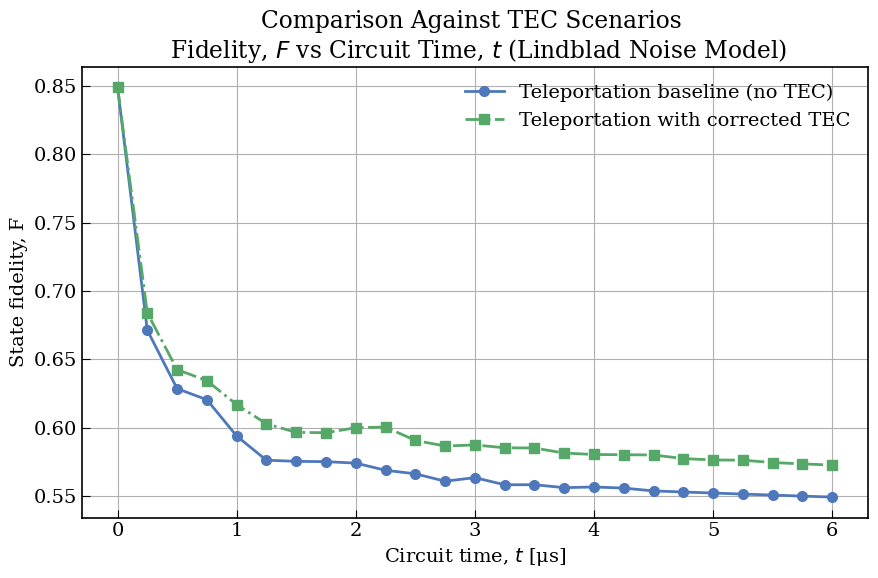

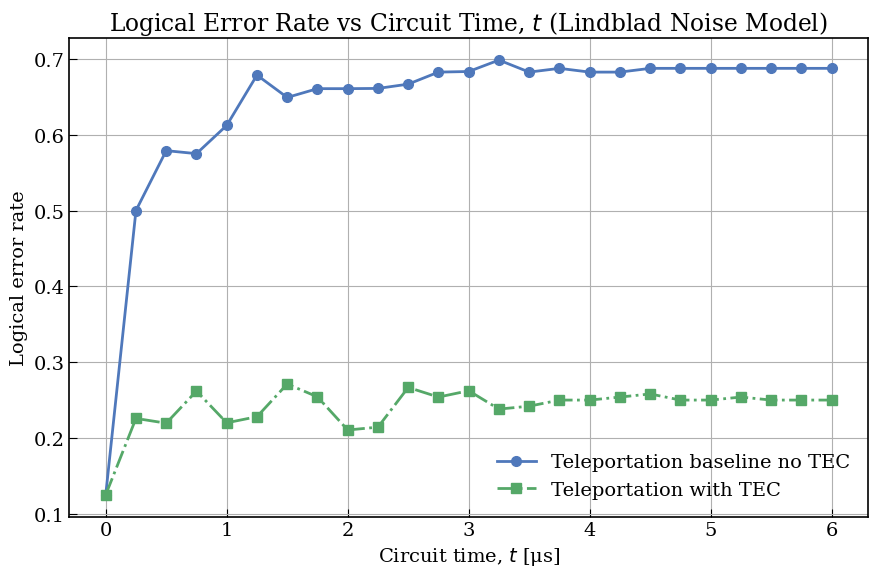

In [3]:
#_____________________________________________________________________________________________________________________
# PART II:
# Superconducting qubit Lindblad Teleportation Error Correction (TEC) - Sandra Nodar Sanchez
#
# The encoded teleportation with and without stabilisers but with the physical noise Lindblad model using 
# superconducting qubits for IBM implementations. 
#

#   - Physical noise is the Lindblad model that is mapped as a single qubit depolarising channel that Qiskit 
#     is able to simulate 
#
#     Physical hardware implementations:
#             - Tphi  --->  dephasing time of the superconducting qubit (in microseconds)
#             - t     ---> circuit time (evolution time) (in microseconds)

#_____________________________________________________________________________________________________________________

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import DensityMatrix, state_fidelity, Operator
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

#_____________________________________________________________________________________________________________________
# Lindblad ---> depolarizing mapping 
#
# An isotropic Lindblad depolarisation model is assumed as follows:
#
#   p_L(t) = 1 - exp(-4 t / Tphi)
#
#
# Qiskit's depolarizing channel is parameterized by p_Q such that:
#
#   ρ -> (1 - p_Q) ρ + (p_Q / 3) (XρX + YρY + ZρZ)
#
# To be able to implemement into qiskit we use the follwoing mapping of the dpeolarising probability to the lindblad 
# version: 
#
#   p_Q = (3/4) * p_L
#
#_____________________________________________________________________________________________________________________

def p_lindblad_qiskit(time, Tphi):
   
    p_lindblad = 1.0 - np.exp(-4.0 * time / Tphi)
    return 0.75 * p_lindblad

#_____________________________________________________________________________________________________________________
# Fixed unknown input state |ψ⟩  (Phase-0 reference)
#
# As before, a single random pure qubit state |ψ⟩  is chosen on the Bloch sphere and is kept fixed
# This is the logical state that is teleported from Alice to Bob, given by the equation below: 
#
#   |ψ⟩ = cos(θ/2)|0⟩ + e^{iφ} sin(θ/2)|1⟩
#
# with (θ, φ) sampled uniformly over the sphere.
#_____________________________________________________________________________________________________________________

np.random.seed(42)
w, v = np.random.uniform(0, 1, 2)

theta = np.arccos(1 - 2*w)
phi   = 2*np.pi*v

input_state = np.array([np.cos(theta/2), np.exp(1j*phi)*np.sin(theta/2)], dtype=complex)

# Store the ideal state as a density matrix for fidelity comparisons
dm_target = DensityMatrix(input_state)


def encode_repetition(qc, q, state):
    """
    Encodes a single-qubit state |ψ⟩ using the three qubit repetition code.

    The repetition code protects against any bit-flip (X) errors  by 
    encoding the logical qubit across the three physical qubits:

        |0_I⟩ = |000⟩
        |1_I⟩ = |111⟩

      - Initialise qubit q[0] in |ψ⟩ and Copy its state to q[1] and q[2] using CNOT gates.
      
    """
    qc.initialize(state, q[0])
    qc.cx(q[0], q[1])
    qc.cx(q[0], q[2])

def prepare_encoded_bell_pair(qc, a, b):

    qc.h(a[0])
    qc.cx(a[0], b[0])

    qc.cx(a[0], a[1])
    qc.cx(a[0], a[2])

    qc.cx(b[0], b[1])
    qc.cx(b[0], b[2])

def idle_markers(qc, q):
   
    # Inserts the identity gates for where we wants the noise to act

    
    for qubit in q:
        qc.id(qubit)

def teleport_encoded(qc, inp, alice, bob, cbits):

    # Bell-basis measurement performed between input and Alice's block
    for i in range(3):
        qc.cx(inp[i], alice[i])
        qc.h(inp[i])
        qc.measure(inp[i], cbits[2*i])
        qc.measure(alice[i], cbits[2*i+1])

    # Apply classical Pauli corrections on Bob's block
    # based on the measurement outcomes stored in 'cbits'.
    for i in range(3):
        with qc.if_test((cbits, 1 << (2*i))):
            qc.x(bob[i])
        with qc.if_test((cbits, 1 << (2*i+1))):
            qc.z(bob[i])


def decode_logical(dm):

    rho = dm.data
    logical = np.array([[rho[0,0], rho[0,7]],[rho[7,0], rho[7,7]]])
    tr = np.trace(logical).real

    if tr < 1e-12:
        
        # If the code space is empty, return as maximally mixed
        return DensityMatrix(np.eye(2)/2)
    return DensityMatrix(logical / tr)

#_____________________________________________________________________________________________________________________
# TEC module (bit-flip correction)
#
# The stabilisers that measure the parity between adjacent qubits are as follows:
#
#   S_1 = Z ⊗ Z ⊗ I   (parity of qubits 0 and 1)
#   S_2 = I ⊗ Z ⊗ Z   (parity of qubits 1 and 2)
#
# Meausuring the stabilisers give two-bit syndromes that can tell us whihc of the qubits have been flipped. TEC uses the 
# to apply a Pauli-X correction on the corresponding qubit before the teleportation process.
#_____________________________________________________________________________________________________________________

def add_tec(qc, data, anc, syn):
    """
    Measure the two stabilisers of the three qubit repetition code.

    The parameters
    --------------
    qc : QuantumCircuit      ---> the circuit where the stabiliser measurements are added. 
        
    data : QuantumRegister   ---> three quibts are encoded on the logical state 
        
    anc : QuantumRegister    ---> Two ancilla qubits are used to obtain the stabiliser eigenvalues 
        
    syn : ClassicalRegister  ---> Classical bits are stored for the stabiliser syndrome outcomes.
        
    """
    # The first stabilsier: Z ⊗ Z ⊗ I on data[0], data[1]
    qc.cx(data[0], anc[0])
    qc.cx(data[1], anc[0])

    qc.measure(anc[0], syn[0])

    # The seconnd stabiliser: I ⊗ Z ⊗ Z on data[1], data[2]
    qc.cx(data[1], anc[1])
    qc.cx(data[2], anc[1])

    qc.measure(anc[1], syn[1])


def apply_tec_correction(qc, data, syn):
    """
    Apply TEC corrections based on the 2-bit syndrome.

    Syndrome mapping for the three qubit repetition code:

        syn = 00  ---> no error has occured
        syn = 01  ---> the error is on qubit 2
        syn = 10  ---> the error is on qubit 0
        syn = 11  ---> the error is on qubit 1

    """
    with qc.if_test((syn, 1)):
        qc.x(data[2])

    with qc.if_test((syn, 2)):
        qc.x(data[0])

    with qc.if_test((syn, 3)):
        qc.x(data[1])

#_____________________________________________________________________________________________________________________
# Circuit builder
#
# We build two circuits:
#
#   - use_TEC = False -> Phase 0 (no TEC)
#   - use_TEC = True  -> Phase 1 (TEC enabled)
#
#   1. Prepare the encoded Bell pair between Alice and Bob.
#   2. Encode the input state into the three qubit repetition code.
#   3. Mark with the idenitity gate where the noise will act, which in our chosen case are the input qubits.
#   4. Optionally for TEC, measure the stabilisers 
#   5. Optionally for TEC with stabiliser corrections, apply the TEC correction.
#   6. Perform the encoded teleportation protocol on the state.
#   7. Save Bob's density matrix, which is conditioned on classical outcomes.
#_____________________________________________________________________________________________________________________

def build_circuit(use_TEC=False):
    """
    Build the encoded teleportation circuit with optional TEC.

    Parameters
    ----------
    use_TEC : bool
        If True, include TEC with stabiliser correction
        If False, no TEC (the baseline teleportation protocol).

    Returns
    -------
    QuantumCircuit
        The constructed circuit with the classical conditional density matrix saving on Bob.

    """
    inp   = QuantumRegister(3, "input")
    alice = QuantumRegister(3, "alice")
    bob   = QuantumRegister(3, "bob")
    anc   = QuantumRegister(2, "anc")
    syn   = ClassicalRegister(2, "syn")
    cbob  = ClassicalRegister(6, "cbob")

    qc = QuantumCircuit(inp, alice, bob, anc, syn, cbob)

    prepare_encoded_bell_pair(qc, alice, bob)
    encode_repetition(qc, inp, input_state)
    idle_markers(qc, inp)

    if use_TEC:
        add_tec(qc, inp, anc, syn)
        apply_tec_correction(qc, inp, syn)

    teleport_encoded(qc, inp, alice, bob, cbob)
    qc.save_density_matrix(bob, label="rho", conditional=True)
    return qc

#_____________________________________________________________________________________________________________________
# Pauli frame aware reconstructed fidelity + logical error rate
#
# As before, we:
#   - Run a density-matrix simulation with conditional states on Bob.
#   - For each classical branch:
#       * Decode the logical state.
#       * Compute the Pauli frame (x, z) from teleportation bits.
#       * Apply that frame to the ideal target.
#       * Compute fidelity.
#       * Identify whether a logical error occurred (I vs X/Z/Y).
#   - Average fidelity over branches.
#   - Compute logical error rate as fraction of branches with non-identity
#     logical error.
#_____________________________________________________________________________________________________________________

PAULI = {
    (0,0): Operator(np.eye(2)),
    (1,0): Operator([[0,1],[1,0]]),        # X-Pauli error
    (0,1): Operator([[1,0],[0,-1]]),       # Z-Pauli error
    (1,1): Operator([[0,-1j],[1j,0]])      # Y-Pauli error
}

def identify_logical_error(decoded, target):
    """
    Identifies which logical Pauli error (I, X, Z, Y) maps the ideal state to
    the decoded state.

    The parameters
    --------------
    decoded : DensityMatrix ---> The decoded logical state from Bob's block.
       
    target : DensityMatrix ---> The ideal state after the Pauli frame. 
    

    Returns
    -------
    str
        One of "I", "X", "Z", "Y",  that indicates which of the logical errors
        were more likely.

    """
    F_I = state_fidelity(target, decoded)
    F_X = state_fidelity(target.evolve(PAULI[(1,0)]), decoded)
    F_Z = state_fidelity(target.evolve(PAULI[(0,1)]), decoded)
    F_Y = state_fidelity(target.evolve(PAULI[(1,1)]), decoded)

    F = [F_I, F_X, F_Z, F_Y]
    labels = ["I", "X", "Z", "Y"]
    return labels[np.argmax(F)]


def reconstructed_fidelity(qc, p_dep):
    """
    Compute reconstructed fidelity and logical error rate for a given
    circuit and with the depolarising probability p_dep.

    The used parameters
    -------------------
    qc : QuantumCircuit ---> The three qubit encoded teleportation circuit (with or without TEC).
        
    p_dep : float ----> The derived depolarising probability from the Lindblad model 
       

    Returns
    -------
    (float, float)
        F : the average reconstructed fidelity
        P_logical : the logical error rate

    """
    # Builds a noise model with the depolarising noise on all identity 'id' gates
    noise = NoiseModel()
    noise.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['id'])

    sim = AerSimulator(method="density_matrix", noise_model=noise)
    qc_t = transpile(qc, sim, optimization_level=0)
    result = sim.run(qc_t).result()

    F = 0.0
    logical_samples = []

    data = result.data(0)["rho"]

    for key, dm in data.items():

        # six bit string for the classical teleportation bits
        bits = format(int(key,16), "06b")

        # Net logical Pauli frame from the teleportation outcomes
        x = sum(int(bits[2*i])   for i in range(3)) % 2
        z = sum(int(bits[2*i+1]) for i in range(3)) % 2

        decoded = decode_logical(DensityMatrix(dm))
        target = dm_target.evolve(PAULI[(x,z)])

        F += state_fidelity(target, decoded)

        # Classification of the logical error 
        err = identify_logical_error(decoded, target)
        logical_samples.append(0 if err == "I" else 1)

    F /= len(data)
    P_logical = sum(logical_samples) / len(logical_samples)

    return F, P_logical

#_____________________________________________________________________________________________________________________
# Hardware-aligned parameters
#
# Realistic hardware parameters are chosen as the following:
#
#   - Tphi : dephasing time of a superconducting qbit (80 μs, representative of IBM)
#   - Circuit_time : Circuit time, swept from 0 to 6μs
#
# For each Circuit_time:
#   - Map (Circuit_time, Tphi) -> p_dep via p_lindblad_qiskit
#   - Evaluate both:
#       * Phase 0 (no TEC)
#       * Phase 1 (TEC)
#   - Store the reconstructed fidelity and logical error rate 
#_____________________________________________________________________________________________________________________

Tphi = 80.0       # microseconds 

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# KEY element for plotting and computing time
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# Range of Circuit_time:
#     - Every point is computationally intensive
#     - 25 spaced points selected as a balance

Circuit_time = np.linspace(0.0, 6.0, 25)  # microseconds

qc_base = build_circuit(use_TEC=False)
qc_tec  = build_circuit(use_TEC=True)

fid_base = []
fid_tec  = []
log_base = []
log_tec  = []

for t in Circuit_time:
    p_eff = p_lindblad_qiskit(t, Tphi)

    F0, L0 = reconstructed_fidelity(qc_base, p_eff)
    F1, L1 = reconstructed_fidelity(qc_tec,  p_eff)

    fid_base.append(F0)
    fid_tec.append(F1)
    log_base.append(L0)
    log_tec.append(L1)

#_____________________________________________________________________________________________________________________
# Plots
#
#   1. Reconstructed fidelity vs TEC cycle time Circuit_time
#   2. Logical error rate vs TEC cycle time Circuit_time
#_____________________________________________________________________________________________________________________

# --- Scientific styling ---
mpl.rcParams.update({"font.size": 14,"font.family": "serif","axes.linewidth": 1.2,"xtick.major.size": 6,"ytick.major.size": 6,
    "xtick.direction": "in","ytick.direction": "in","legend.frameon": False})

#-----------------------------------------------------------------------------
# 1) Reconstructed fidelity vs TEC cycle time Circuit_time
#-----------------------------------------------------------------------------

plt.figure(figsize=(9,6))
plt.plot(Circuit_time, fid_base, 'o-', label="Teleportation baseline (no TEC)", color = "#4F78BB",markersize=7,linewidth=2)
plt.plot(Circuit_time, fid_tec,  's-.', label="Teleportation with corrected TEC", color = "#55A868",markersize=7,linewidth=2)
plt.xlabel("Circuit time, $t$ [μs]")
plt.ylabel("State fidelity, F")
plt.title("Comparison Against TEC Scenarios \n Fidelity, $F$ vs Circuit Time, $t$ (Lindblad Noise Model)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#-----------------------------------------------------------------------------
# 2) Logical error rate vs TEC cycle time t
#-----------------------------------------------------------------------------

plt.figure(figsize=(9,6))
plt.plot(Circuit_time, log_base, 'o-',  label="Teleportation baseline no TEC", color = "#4F78BB",markersize=7,linewidth=2)
plt.plot(Circuit_time, log_tec,  's-.',  label="Teleportation with TEC", color = "#55A868",markersize=7,linewidth=2)
plt.xlabel("Circuit time, $t$ [μs]")
plt.ylabel("Logical error rate")
plt.title("Logical Error Rate vs Circuit Time, $t$ (Lindblad Noise Model)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
